In [1]:
!pip3 install seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [3]:
import pandas as pd

df = pd.read_csv('data.csv')

print(df.head())

       Z  age  gender  study_hours_per_day  social_media_hours  netflix_hours  \
0  S1000   23  Female                  0.0                 1.2            1.1   
1  S1001   20  Female                  6.9                 2.8            2.3   
2  S1002   21    Male                  1.4                 3.1            1.3   
3  S1003   23  Female                  1.0                 3.9            1.0   
4  S1004   19  Female                  5.0                 4.4            0.5   

  part_time_job  attendance_percentage  sleep_hours diet_quality  \
0            No                   85.0          8.0         Fair   
1            No                   97.3          4.6         Good   
2            No                   94.8          8.0         Poor   
3            No                   71.0          9.2         Poor   
4            No                   90.9          4.9         Fair   

   exercise_frequency parental_education_level internet_quality  \
0                   6                

In [4]:
#show basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Z                              1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [5]:
#check for missing value
print(df.isnull().sum())

Z                                 0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


In [6]:
#describe numerical features
print(df.describe())

             age  study_hours_per_day  social_media_hours  netflix_hours  \
count  1000.0000           1000.00000         1000.000000    1000.000000   
mean     20.4980              3.55010            2.505500       1.819700   
std       2.3081              1.46889            1.172422       1.075118   
min      17.0000              0.00000            0.000000       0.000000   
25%      18.7500              2.60000            1.700000       1.000000   
50%      20.0000              3.50000            2.500000       1.800000   
75%      23.0000              4.50000            3.300000       2.525000   
max      24.0000              8.30000            7.200000       5.400000   

       attendance_percentage  sleep_hours  exercise_frequency  \
count            1000.000000  1000.000000         1000.000000   
mean               84.131700     6.470100            3.042000   
std                 9.399246     1.226377            2.025423   
min                56.000000     3.200000            0.

In [7]:
#show correlation for exam

correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix['exam_score'].sort_values(ascending=False))

exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


In [8]:
#visualization 


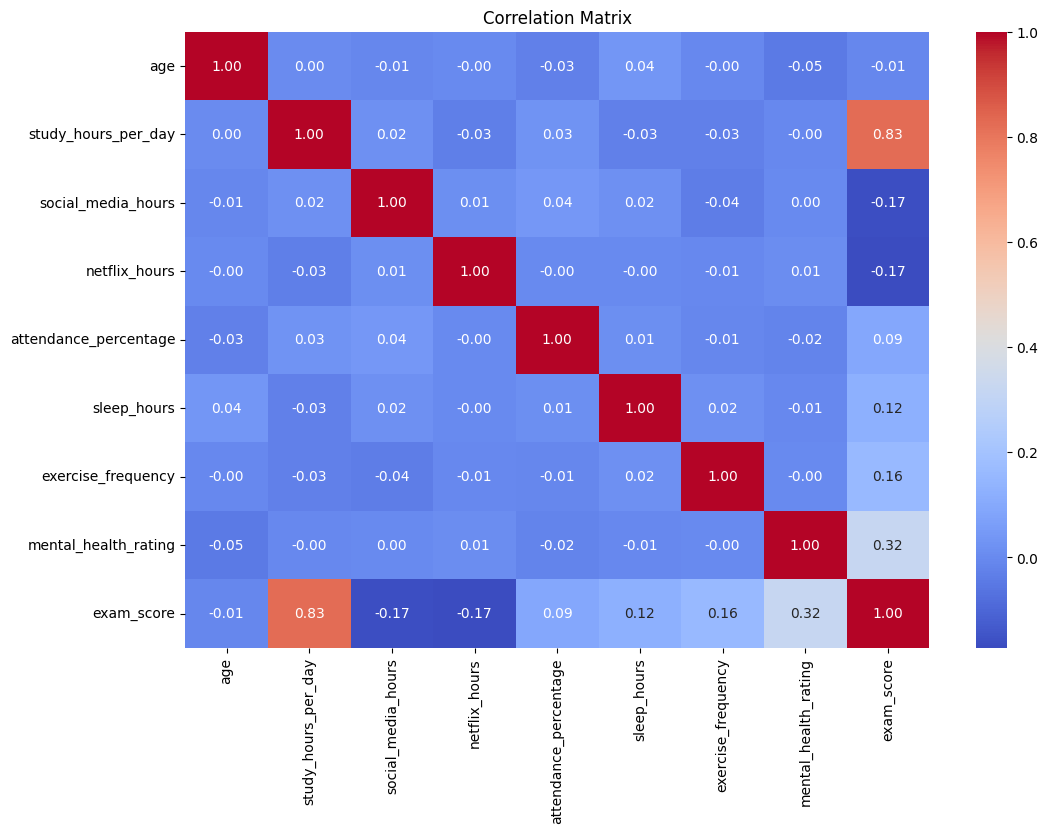

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [10]:
# averange example score by gender

print(df.groupby('gender')['exam_score'].mean())

gender
Female    69.741372
Male      69.368344
Other     70.647619
Name: exam_score, dtype: float64


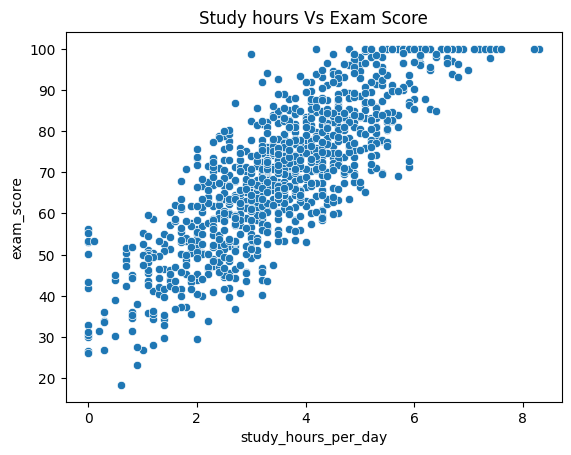

In [11]:
sns.scatterplot(data=df,x='study_hours_per_day',y='exam_score')
plt.title('Study hours Vs Exam Score')
plt.show()

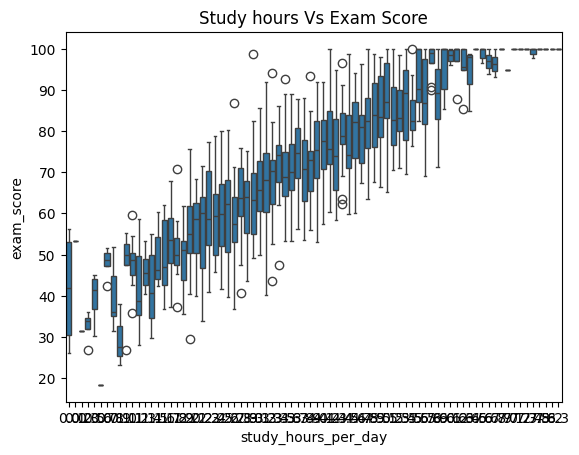

In [12]:
sns.boxplot(data=df,x='study_hours_per_day',y='exam_score')
plt.title('Study hours Vs Exam Score')
plt.show()

In [13]:

df = pd.read_csv('data.csv')

In [14]:
df

,Z,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,S1995,21,Female,2.6,0.5,1.6,No,77.0,7.5,Fair,2,High School,Good,6,Yes,76.1
996,S1996,17,Female,2.9,1.0,2.4,Yes,86.0,6.8,Poor,1,High School,Average,6,Yes,65.9
997,S1997,20,Male,3.0,2.6,1.3,No,61.9,6.5,Good,5,Bachelor,Good,9,Yes,64.4
998,S1998,24,Male,5.4,4.1,1.1,Yes,100.0,7.6,Fair,0,Bachelor,Average,1,No,69.7


In [15]:
# average exam score by sleep_hours
print(df.groupby('sleep_hours')['exam_score'].mean())

sleep_hours
3.2     90.800000
3.3     62.000000
3.4     49.900000
3.5     62.250000
3.6     62.000000
          ...    
9.5     73.266667
9.6     66.200000
9.7     80.450000
9.8     78.700000
10.0    84.900000
Name: exam_score, Length: 68, dtype: float64


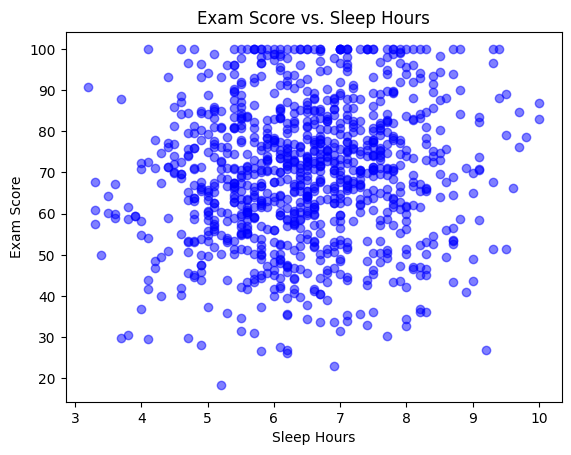

In [16]:
import matplotlib.pyplot as plt

sleep_hours = df['sleep_hours']
exam_scores =df['exam_score']

plt.scatter(sleep_hours,exam_scores,color='blue', alpha=0.5)

plt.xlabel('Sleep Hours')
plt.ylabel('Exam Score')
plt.title('Exam Score vs. Sleep Hours')

plt.show()

In [17]:
#count student  by gender and part time job
print(df.groupby(['gender','part_time_job']).size())

gender  part_time_job
Female  No               385
        Yes               96
Male    No               368
        Yes              109
Other   No                32
        Yes               10
dtype: int64


In [18]:
#average study hours for student with or without part-time job
print(df.groupby('part_time_job')['study_hours_per_day'].mean())

part_time_job
No     3.572484
Yes    3.468372
Name: study_hours_per_day, dtype: float64


In [19]:
# check the productitvty score

df['productivity_ratio'] = df['study_hours_per_day'] / (df['social_media_hours'] + df['netflix_hours'] + 1)

In [20]:
print(df['productivity_ratio'])

0      0.000000
1      1.131148
2      0.259259
3      0.169492
4      0.847458
         ...   
995    0.838710
996    0.659091
997    0.612245
998    0.870968
999    0.741379
Name: productivity_ratio, Length: 1000, dtype: float64


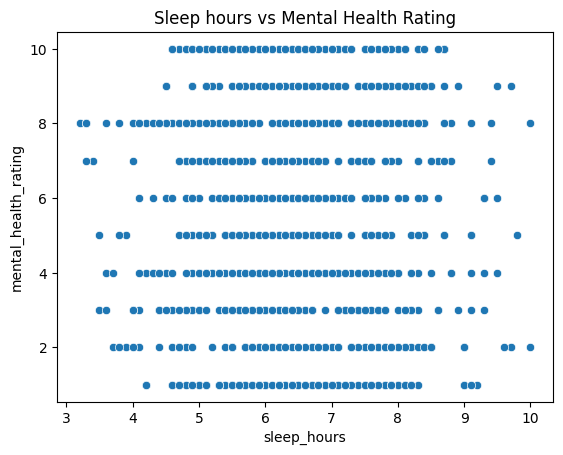

In [21]:
#relationship between mental health and sleep hours

sns.scatterplot(data=df,x='sleep_hours',y='mental_health_rating')
plt.title('Sleep hours vs Mental Health Rating')
plt.show()

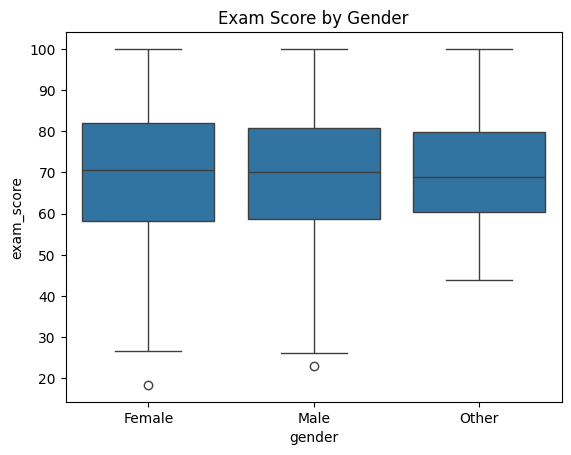

In [22]:
sns.boxplot(data=df,x='gender',y='exam_score')
plt.title('Exam Score by Gender')
plt.show()

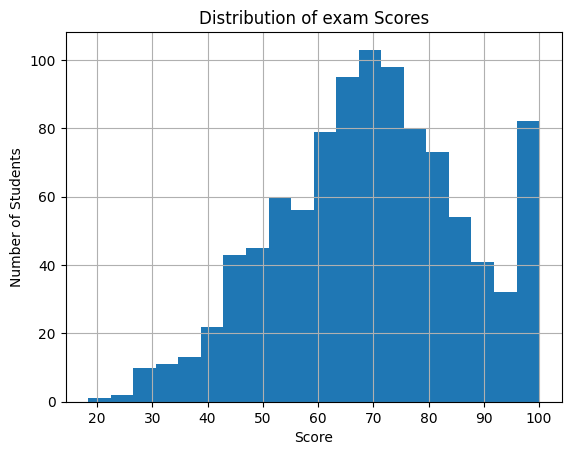

In [23]:
#histogram of exam scores

df['exam_score'].hist(bins=20)
plt.title('Distribution of exam Scores')
plt.xlabel('Score')
plt.ylabel('Number of Students')
plt.show()

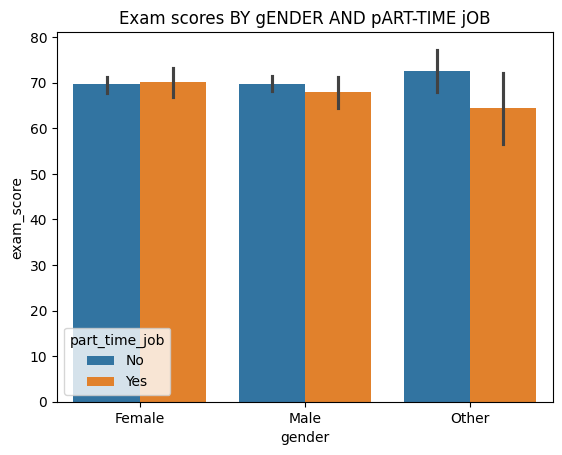

In [24]:
#Average exam socre by gender and part-time job:

sns.barplot(data=df,x='gender',y='exam_score',hue='part_time_job')
plt.title('Exam scores BY gENDER AND pART-TIME jOB')
plt.show()

In [25]:
#total screen time 
df['total_screen_time'] = df['social_media_hours'] + df['netflix_hours']

In [26]:
#total screen time of each gender on social phone or computer
print(df.groupby('gender')['total_screen_time'].sum())

gender
Female    2069.2
Male      2060.7
Other      195.3
Name: total_screen_time, dtype: float64


In [27]:
#average screen time of each gender on phone or computer

print(df.groupby('gender')['total_screen_time'].mean())

gender
Female    4.301871
Male      4.320126
Other     4.650000
Name: total_screen_time, dtype: float64


In [28]:
# efficency score per study hour

df['efficiency_score'] = df['exam_score'] / (df['study_hours_per_day'] + 1)

In [29]:
print(df['efficiency_score'])

0      56.200000
1      12.658228
2      14.291667
3      13.400000
4      11.066667
         ...    
995    21.138889
996    16.897436
997    16.100000
998    10.890625
999    14.132075
Name: efficiency_score, Length: 1000, dtype: float64


In [30]:
#efficiency_score per student by average
print(df.groupby('gender')['efficiency_score'].mean())

gender
Female    16.221694
Male      16.273845
Other     15.583723
Name: efficiency_score, dtype: float64


In [31]:
def top_correlated_features(df, target, n=5):
    corr = df.corr(numeric_only=True)[target].abs().sort_values(ascending=False)
    return corr[1:n+1]  # skip target itself

print(top_correlated_features(df, 'exam_score'))

study_hours_per_day     0.825419
productivity_ratio      0.707269
mental_health_rating    0.321523
total_screen_time       0.237631
efficiency_score        0.200023
Name: exam_score, dtype: float64


In [32]:
pivot = df.pivot_table(values='exam_score',
                       index='parental_education_level',
                       columns='extracurricular_participation',
                       aggfunc='mean')
print(pivot)

extracurricular_participation         No        Yes
parental_education_level                           
Bachelor                       70.735169  69.314912
High School                    69.074254  70.569355
Master                         68.068966  68.127451


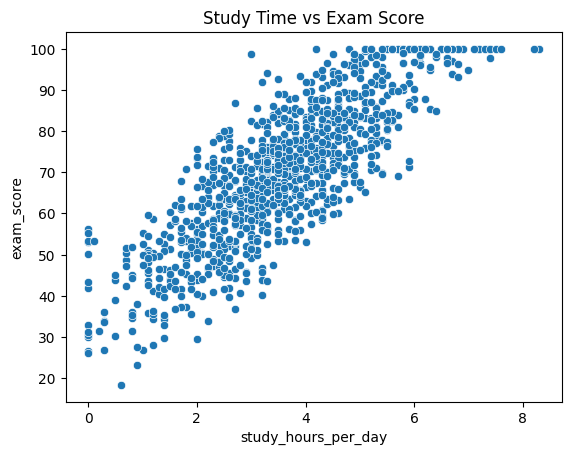

In [34]:
sns.scatterplot(x='study_hours_per_day',y='exam_score',data=df)
plt.title('Study Time vs Exam Score')
plt.show()

In [35]:
df['performance'] = df['exam_score'].apply(lambda x: 'Pass' if x >= 60 else 'Fail')
print(df[['Z','exam_score','performance']])

         Z  exam_score performance
0    S1000        56.2        Fail
1    S1001       100.0        Pass
2    S1002        34.3        Fail
3    S1003        26.8        Fail
4    S1004        66.4        Pass
..     ...         ...         ...
995  S1995        76.1        Pass
996  S1996        65.9        Pass
997  S1997        64.4        Pass
998  S1998        69.7        Pass
999  S1999        74.9        Pass

[1000 rows x 3 columns]


In [36]:
print(df[df['study_hours_per_day']> 2])

         Z  age  gender  study_hours_per_day  social_media_hours  \
1    S1001   20  Female                  6.9                 2.8   
4    S1004   19  Female                  5.0                 4.4   
5    S1005   24    Male                  7.2                 1.3   
6    S1006   21  Female                  5.6                 1.5   
7    S1007   21  Female                  4.3                 1.0   
..     ...  ...     ...                  ...                 ...   
995  S1995   21  Female                  2.6                 0.5   
996  S1996   17  Female                  2.9                 1.0   
997  S1997   20    Male                  3.0                 2.6   
998  S1998   24    Male                  5.4                 4.1   
999  S1999   19  Female                  4.3                 2.9   

     netflix_hours part_time_job  attendance_percentage  sleep_hours  \
1              2.3            No                   97.3          4.6   
4              0.5            No       

In [37]:
print(df[(df['attendance_percentage'] > 85) & (df['part_time_job']== 'No')])

         Z  age  gender  study_hours_per_day  social_media_hours  \
1    S1001   20  Female                  6.9                 2.8   
2    S1002   21    Male                  1.4                 3.1   
4    S1004   19  Female                  5.0                 4.4   
8    S1008   23  Female                  4.4                 2.2   
9    S1009   18  Female                  4.8                 3.1   
..     ...  ...     ...                  ...                 ...   
990  S1990   18    Male                  3.2                 3.5   
991  S1991   20    Male                  6.0                 2.1   
992  S1992   18    Male                  3.5                 0.0   
993  S1993   20    Male                  3.8                 2.1   
999  S1999   19  Female                  4.3                 2.9   

     netflix_hours part_time_job  attendance_percentage  sleep_hours  \
1              2.3            No                   97.3          4.6   
2              1.3            No       

In [38]:
print(df.groupby('gender')['exam_score'].mean())

gender
Female    69.741372
Male      69.368344
Other     70.647619
Name: exam_score, dtype: float64


In [39]:
print(df['parental_education_level'].value_counts())

parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64
